# Phase-burst coupling

The phase-burst coupling (PBC) measure compares the entropy of this distribution with that of the uniform distribution and reflects the degree to which bursts cluster at particular phases of the beta wave.

$$
PBC(t) = \frac{H_U – H_{PB}(t)}{H_U},
$$

where $H = -\sum_k p_k \ln p_k$ is entropy, $H_U$ denotes entropy of the uniform distribution, and $H_{PB}(t)$ denotes entropy of the phase-burst distribution at time $t$.

In [1]:
import sys, os
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

from burst_toolbox.coupling import phase_histogram, phase_burst_coupling

## PBC on synthetic data

In this example, we position high gamma (30 ms) bursts at random peaks of 16-Hz beta waves over 100 trials and compare the resulting PBC with the case of random burst positioning.

In [2]:
# Generate 100 16-Hz beta waves with random phase shifts
freq = 16
n_trials = 100

t = np.arange(0, 6500)

# Generate trials
random_state = np.random.RandomState(123)

# Phase shift
random_phase_shfit = np.zeros(n_trials)
random_phase_shfit = random_state.uniform(-np.pi, np.pi, n_trials)

beta_trace = np.array([np.cos(2 * np.pi * freq * t / 1000 + random_phase_shfit[trial_idx]) for trial_idx in range(n_trials)])
beta_trace.shape

(100, 6500)

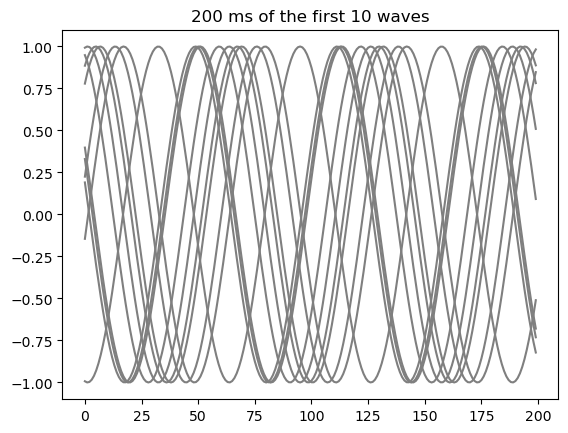

In [3]:
# Plot the first 10 waves
plt.plot(beta_trace[:10, :200].T, color = "tab:gray")
plt.title("200 ms of the first 10 waves");

We compare burst positioning over 15 random peaks vs 15 random angles.

In [13]:
burst_duration = 30 # (ms)
n_bursts = 15
bursts = np.zeros((2, n_trials, 6500)) # (peaks vs random, n_trials, time)

random_state = np.random.RandomState(123)

for trial_idx in range(n_trials):

    # Get random peak positions
    peaks = np.where(beta_trace[trial_idx, :] > 0.99)[0]
    peaks = random_state.choice(peaks, n_bursts, replace = False)

    # Get random angle positions
    rand_positions = random_state.randint(low = burst_duration + 10, high = 6500 - burst_duration - 10, size = n_bursts)

    for burst_id in range(len(peaks)):
        duration = random_state.normal(burst_duration, 1)
        bursts[0, trial_idx, int(peaks[burst_id] - duration / 2) : int(peaks[burst_id] + duration / 2)] = 1
        bursts[1, trial_idx, int(rand_positions[burst_id] - duration / 2) : int(rand_positions[burst_id] + duration / 2)] = 1

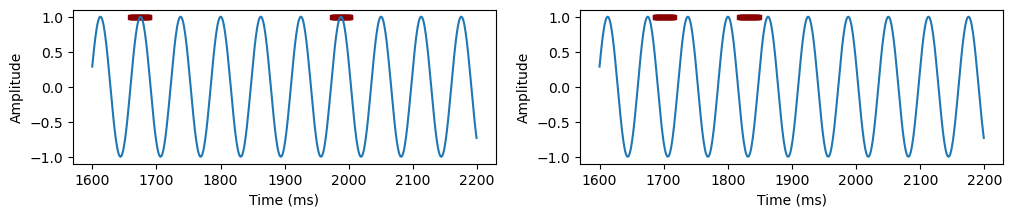

In [14]:
time_period = (1600, 2200)

fig, ax = plt.subplots(1, 2, figsize = (12, 2))

for col_id, title in enumerate(["Random peaks", "Random"]):
    ca = ax[col_id]
    ca.plot(range(time_period[0], time_period[1]), beta_trace[0, time_period[0] : time_period[1]])

    bursts_to_plot = bursts[col_id, 0, time_period[0] : time_period[1]].copy()
    bursts_to_plot[bursts_to_plot == 0] = np.nan
    ca.scatter(range(time_period[0], time_period[1]), bursts_to_plot, marker = "s", s = 10, color = 'darkred')

    ca.set_xlabel("Time (ms)")
    ca.set_ylabel("Amplitude")
    ca.set_title

Next, we compute per-trial phase-burst counts and estimate PBC.

In [16]:
res = []

for burst_type_idx, burst_type_name in enumerate(["Random peaks", "Random"]):
    # Compute PBC
    phase_burst_counts = phase_histogram(
        LFP = beta_trace, 
        events = bursts[burst_type_idx], 
        phase_freq_band = np.array([12, 30]))
    pbc, phase_dist = phase_burst_coupling(phase_burst_counts)
    print(f"{burst_type_name}: avg PBC = {np.nanmean(pbc)}")

    # Normalize distribution
    distr = np.nanmean(phase_dist, axis = 0)
    distr = distr / np.sum(distr)

    res.append((pbc, distr))

Random peaks: avg PBC = 0.22236791566253325
Random: avg PBC = 0.0028872272278017276


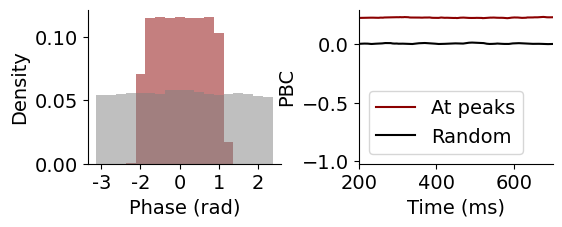

In [17]:
plt.rcParams.update({"font.size": 14})
edge_labels = np.round(np.deg2rad(np.array([-180 + d * 20 for d in range(18)]))).astype(int)

fig, ax = plt.subplots(1, 2, figsize = (6, 2))
ca = ax[0]

ca.bar(range(0, 5 * 18, 5), res[0][1], width = 5, color = 'darkred', alpha = 0.5)
ca.bar(range(0, 5 * 18, 5), res[1][1], width = 5, color = 'gray', alpha = 0.5)
ca.set_xticks(range(0, 5 * 18, 5)[::4])
ca.set_xticklabels(edge_labels[::4])
ca.set_xlabel("Phase (rad)")
ca.set_ylabel("Density")
ca.spines[["top", "right"]].set_visible(False)

ca = ax[1]
ca.plot(t, res[0][0], color = 'darkred', label = "At peaks")
ca.plot(t, res[1][0], color = 'black', label = "Random")
ca.set_xlim(200, 700)

ca.set_xlabel("Time (ms)")
ca.set_ylabel("PBC")
ca.spines[["top", "right"]].set_visible(False)
ca.legend()

plt.subplots_adjust(wspace = 0.4)